# IMU – Espontaneidad Global del Movimiento (MDS-UPDRS 3.14)

**Paciente con Parkinson**

La prueba 3.14 del MDS-UPDRS evalúa la **bradicinesia global del cuerpo**
(lentitud, pobreza de movimiento y reducción de amplitud espontánea).

**Enfoque final acordado:**
- 3.14 ya no depende de un único archivo de entrada.
- Se calcula con el **promedio de resultados de las pruebas 3.15, 3.16 y 3.17**.
- Se reporta estadística descriptiva (media y desviación estándar) y clasificación en rangos MDS-UPDRS.

**IMUs objetivo del protocolo:**
- LEFT-HAND, RIGHT-HAND, BASE-SPINE, LEFT-ANKLE, RIGHT-ANKLE.

Qué hace este notebook:
- Carga y unifica señales de 3.15, 3.16 y 3.17 (incluyendo extracción robusta de `dgiResults[].imuData` para 3.17).
- Calcula métricas por prueba y por IMU.
- Agrega por promedio entre pruebas (media/desviación estándar).
- Clasifica rangos MDS-UPDRS 3.14 a partir de esos promedios.

In [17]:
# Imports y utilidades (con alternativas si SciPy no está)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [18]:
# Carga de JSON y aplanado multi-prueba (3.15–3.17)
from pathlib import Path
from collections.abc import Mapping, Sequence

TEST_FILES = {
    '3.15': [Path('../Datos/Parkinson/3.15-Parkinson.json')],
    '3.16': [
        Path('../Datos/Parkinson/3.16-LEFT-HAND-Parkinson.json'),
        Path('../Datos/Parkinson/3.16-RIGHT-HAND-Parkinson.json'),
    ],
    '3.17': [Path('../Datos/Parkinson/3.17-Parkinson.json')],
}


def _to_number(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def _extract_imu_records(obj, out_list):
    if isinstance(obj, Mapping):
        for k, v in list(obj.items()):
            if isinstance(v, str) and v and v.strip().startswith(('{', '[')):
                try:
                    obj[k] = json.loads(v)
                except Exception:
                    pass

        acc = obj.get('accelerometer')
        gyr = obj.get('gyroscope')
        dev = obj.get('deviceId') or obj.get('device') or obj.get('placement') or obj.get('name')
        ts = obj.get('timestamp') or obj.get('time') or obj.get('ts')

        if (isinstance(acc, Mapping) or isinstance(gyr, Mapping)) and (dev is not None) and (ts is not None):
            out_list.append({
                'deviceId': str(dev),
                'timestamp_ms': _to_number(ts),
                'ax': _to_number((acc or {}).get('x', np.nan)),
                'ay': _to_number((acc or {}).get('y', np.nan)),
                'az': _to_number((acc or {}).get('z', np.nan)),
                'gx': _to_number((gyr or {}).get('x', np.nan)),
                'gy': _to_number((gyr or {}).get('y', np.nan)),
                'gz': _to_number((gyr or {}).get('z', np.nan)),
            })

        for v in obj.values():
            _extract_imu_records(v, out_list)

    elif isinstance(obj, Sequence) and not isinstance(obj, (str, bytes, bytearray)):
        for it in obj:
            _extract_imu_records(it, out_list)


rows = []
patient = {}

for source_test, paths in TEST_FILES.items():
    for path in paths:
        assert path.exists(), f'No se encontró el archivo: {path}'
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        if not patient and isinstance(data, Mapping):
            patient = data.get('patient', {}) or {}

        imu_data = data.get('imuData', []) if isinstance(data, Mapping) else []
        if isinstance(imu_data, str) and imu_data.strip().startswith(('{', '[')):
            try:
                imu_data = json.loads(imu_data)
            except Exception:
                imu_data = []

        local_rows = []
        if isinstance(imu_data, list) and imu_data:
            for p in imu_data:
                acc = (p.get('accelerometer', {}) if isinstance(p, Mapping) else {}) or {}
                gyr = (p.get('gyroscope', {}) if isinstance(p, Mapping) else {}) or {}
                local_rows.append({
                    'deviceId': (p.get('deviceId') if isinstance(p, Mapping) else 'UNKNOWN') or 'UNKNOWN',
                    'timestamp_ms': _to_number(p.get('timestamp') if isinstance(p, Mapping) else np.nan),
                    'ax': _to_number(acc.get('x', np.nan)),
                    'ay': _to_number(acc.get('y', np.nan)),
                    'az': _to_number(acc.get('z', np.nan)),
                    'gx': _to_number(gyr.get('x', np.nan)),
                    'gy': _to_number(gyr.get('y', np.nan)),
                    'gz': _to_number(gyr.get('z', np.nan)),
                })
        else:
            _extract_imu_records(data, local_rows)

        for r in local_rows:
            r['source_test'] = source_test
            r['source_run'] = path.stem
            r['source_file'] = path.name

        rows.extend(local_rows)

columns = [
    'source_test', 'source_run', 'source_file',
    'deviceId', 'timestamp_ms', 'ax', 'ay', 'az', 'gx', 'gy', 'gz'
]
df = pd.DataFrame(rows, columns=columns)
assert not df.empty, 'No se encontraron registros IMU en 3.15–3.17'

df = (
    df.dropna(subset=['timestamp_ms', 'deviceId'])[columns]
      .sort_values(['source_test', 'source_run', 'deviceId', 'timestamp_ms'])
      .reset_index(drop=True)
)

print(f'Registros IMU agregados: {len(df)}')
print('Paciente:', patient)

counts_df = (
    df.groupby(['source_test', 'source_run', 'deviceId'], as_index=False)
      .size()
      .rename(columns={'size': 'n_samples'})
)
display(counts_df)

df.head()

Registros IMU agregados: 21034
Paciente: {'birthDate': '17/04/1967', 'id': '16751329', 'name': 'Luis Felipe Jojoa Lasso', 'observations': 'prueba Felipe Manos extendidas por 10 segundos Toma 2 correcta ignorar la primera porque no guardaba'}


,source_test,source_run,deviceId,n_samples
0,3.15,3.15-Parkinson,BASE-SPINE,779
1,3.15,3.15-Parkinson,LEFT-HAND,674
2,3.15,3.15-Parkinson,RIGHT-HAND,742
3,3.16,3.16-LEFT-HAND-Parkinson,BASE-SPINE,1721
4,3.16,3.16-LEFT-HAND-Parkinson,LEFT-HAND,1471
5,3.16,3.16-LEFT-HAND-Parkinson,RIGHT-HAND,1667
6,3.16,3.16-RIGHT-HAND-Parkinson,BASE-SPINE,3744
7,3.16,3.16-RIGHT-HAND-Parkinson,LEFT-HAND,2804
8,3.16,3.16-RIGHT-HAND-Parkinson,RIGHT-HAND,3680
9,3.17,3.17-Parkinson,BASE-SPINE,851


,source_test,source_run,source_file,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186670.0,1.036987,-0.150513,-0.055664,-1.647949,-11.169430,-1.647949
1,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186696.0,1.034180,-0.142334,-0.052002,-1.037598,-7.812500,-1.464844
2,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186722.0,1.018921,-0.137573,-0.050171,-0.366211,-6.530762,-1.159668
3,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186748.0,1.031494,-0.140991,-0.044434,0.000000,-4.638672,-0.732422
4,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186775.0,1.017456,-0.141113,-0.056274,1.220703,-5.065918,-1.220703


In [19]:
# Preprocesamiento y selección de tramo común por ejecución
EXPECTED_314_DEVICES = ['BASE-SPINE', 'LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']


def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms) / 1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0 / med


def canonical_device_name(dev: str) -> str:
    d = str(dev or '').upper().replace('_', '-')
    if 'BASE' in d and 'SPINE' in d:
        return 'BASE-SPINE'
    if 'LEFT' in d and 'HAND' in d:
        return 'LEFT-HAND'
    if 'RIGHT' in d and 'HAND' in d:
        return 'RIGHT-HAND'
    if 'LEFT' in d and ('ANKLE' in d or 'FOOT' in d):
        return 'LEFT-ANKLE'
    if 'RIGHT' in d and ('ANKLE' in d or 'FOOT' in d):
        return 'RIGHT-ANKLE'
    return d


df = df.copy()
df['deviceId'] = df['deviceId'].apply(canonical_device_name)
df['t'] = df.groupby(['source_run', 'deviceId'])['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = sorted(df['deviceId'].dropna().unique().tolist())
analysis_devices = list(EXPECTED_314_DEVICES)

available_expected = [d for d in analysis_devices if d in devices]
missing_expected = [d for d in analysis_devices if d not in devices]
extra_devices = [d for d in devices if d not in analysis_devices]

coverage_314_df = pd.DataFrame({
    'device': analysis_devices,
    'rol': ['TRONCO' if d == 'BASE-SPINE' else 'EXTREMIDAD' for d in analysis_devices],
    'en_datos': [d in devices for d in analysis_devices],
})

print('IMUs esperadas (3.14):', analysis_devices)
print('IMUs detectadas en 3.15–3.17:', devices)
print('IMUs faltantes:', missing_expected if missing_expected else 'Ninguna')
if extra_devices:
    print('IMUs extra detectadas:', extra_devices)
display(coverage_314_df)

run_meta = (
    df[['source_test', 'source_run', 'source_file']]
      .drop_duplicates()
      .sort_values(['source_test', 'source_run'])
      .reset_index(drop=True)
)

win_frames = []
fs_rows = []

for _, meta in run_meta.iterrows():
    run = meta['source_run']
    source_test = meta['source_test']
    run_df = df[df['source_run'] == run].copy()

    per_dev_max = run_df.groupby('deviceId')['t'].max()
    per_dev_min = run_df.groupby('deviceId')['t'].min()
    if per_dev_min.empty or per_dev_max.empty:
        continue

    global_min = float(per_dev_min.max())
    global_max = float(per_dev_max.min())

    if global_max <= global_min:
        start_t = float(run_df['t'].min())
        end_t = float(run_df['t'].max())
    else:
        start_t = global_min
        end_t = global_max

    run_win = run_df[(run_df['t'] >= start_t) & (run_df['t'] <= end_t)].copy()
    run_win['window_start_t'] = start_t
    run_win['window_end_t'] = end_t
    win_frames.append(run_win)

    for dev in run_df['deviceId'].dropna().unique():
        fs_val = estimate_fs_ms(run_df.loc[run_df['deviceId'] == dev, 'timestamp_ms'].to_numpy())
        fs_rows.append({'source_run': run, 'source_test': source_test, 'device': dev, 'fs': fs_val})

    print(f"Run {run} ({source_test}): tramo [{start_t:.2f}, {end_t:.2f}] s")

assert win_frames, 'No fue posible construir ventanas por ejecución en 3.15–3.17'
df_win = pd.concat(win_frames, ignore_index=True)
assert not df_win.empty, 'No hay datos en ventanas seleccionadas'

fs_df = pd.DataFrame(fs_rows).drop_duplicates(['source_run', 'device']).reset_index(drop=True)
fs_map = fs_df.groupby('device')['fs'].mean().to_dict()

coverage_by_test = (
    df_win.groupby(['source_test', 'deviceId']).size().reset_index(name='n_samples')
)
print('\nCobertura de muestras por prueba:')
display(coverage_by_test)

df_win.head()

IMUs esperadas (3.14): ['BASE-SPINE', 'LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']
IMUs detectadas en 3.15–3.17: ['BASE-SPINE', 'LEFT-ANKLE', 'LEFT-HAND', 'RIGHT-ANKLE', 'RIGHT-HAND']
IMUs faltantes: Ninguna


,device,rol,en_datos
0,BASE-SPINE,TRONCO,True
1,LEFT-HAND,EXTREMIDAD,True
2,RIGHT-HAND,EXTREMIDAD,True
3,LEFT-ANKLE,EXTREMIDAD,True
4,RIGHT-ANKLE,EXTREMIDAD,True


Run 3.15-Parkinson (3.15): tramo [0.00, 20.44] s
Run 3.16-LEFT-HAND-Parkinson (3.16): tramo [0.00, 43.82] s
Run 3.16-RIGHT-HAND-Parkinson (3.16): tramo [0.00, 96.98] s
Run 3.17-Parkinson (3.17): tramo [0.00, 22.36] s

Cobertura de muestras por prueba:


,source_test,deviceId,n_samples
0,3.15,BASE-SPINE,779
1,3.15,LEFT-HAND,663
2,3.15,RIGHT-HAND,713
3,3.16,BASE-SPINE,5358
4,3.16,LEFT-HAND,4247
5,3.16,RIGHT-HAND,5347
6,3.17,BASE-SPINE,753
7,3.17,LEFT-ANKLE,558
8,3.17,LEFT-HAND,854
9,3.17,RIGHT-ANKLE,652


,source_test,source_run,source_file,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag,window_start_t,window_end_t
0,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186670.0,1.036987,-0.150513,-0.055664,-1.647949,-11.169430,-1.647949,0.000,1.049331,11.409980,0.0,20.444
1,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186696.0,1.034180,-0.142334,-0.052002,-1.037598,-7.812500,-1.464844,0.026,1.045223,8.016080,0.0,20.444
2,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186722.0,1.018921,-0.137573,-0.050171,-0.366211,-6.530762,-1.159668,0.052,1.029390,6.643026,0.0,20.444
3,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186748.0,1.031494,-0.140991,-0.044434,0.000000,-4.638672,-0.732422,0.078,1.042033,4.696139,0.0,20.444
4,3.15,3.15-Parkinson,3.15-Parkinson.json,BASE-SPINE,186775.0,1.017456,-0.141113,-0.056274,1.220703,-5.065918,-1.220703,0.105,1.028735,5.351986,0.0,20.444


In [20]:
# Cálculo de métricas 3.14 por prueba y agregación (promedio 3.15–3.17)
from dataclasses import dataclass


@dataclass
class BradykinesiaResult:
    source_test: str
    source_run: str
    device: str
    fs: float
    mean_acc_mag: float
    std_acc_mag: float
    mean_gyro_mag: float
    std_gyro_mag: float
    mean_jerk: float
    movement_power_ratio: float
    tremor_peak_acc_hz: float
    tremor_ratio_acc: float
    tremor_rms_acc: float
    tremor_flag_acc: bool
    tremor_peak_gyro_hz: float
    tremor_ratio_gyro: float
    tremor_rms_gyro: float
    tremor_flag_gyro: bool
    parkinson_flag_validated: bool
    data_status: str


def detect_tremor(sig: np.ndarray, fs: float,
                  band: Tuple[float, float] = (3.0, 8.0),
                  broad: Tuple[float, float] = (0.5, 15.0),
                  rms_threshold: float = 0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs * 2)):
        return (float('nan'), 0.0, 0.0, 0.0, 0.0, False)

    x = np.asarray(sig, dtype=float) - np.mean(sig)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs * 2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, 0.0, False)

    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, 0.0, False)

    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power / total_power) if total_power > 0 else 0.0

    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')

    y = simple_bandpass(x, fs, band[0], band[1])
    rms = float(np.sqrt(np.mean(y * y))) if y.size else 0.0
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, rms, is_tremor)


def _score_from_pct(pct: float) -> int:
    if not np.isfinite(pct) or pct <= 0:
        return 0
    if pct <= 25:
        return 1
    if pct <= 50:
        return 2
    if pct <= 75:
        return 3
    return 4


def _get_fs(source_run: str, device: str) -> float:
    m = fs_df[(fs_df['source_run'] == source_run) & (fs_df['device'] == device)]
    if m.empty:
        return float(fs_map.get(device, float('nan')))
    return float(m['fs'].iloc[0])


results = []
for _, meta in run_meta.iterrows():
    source_test = meta['source_test']
    source_run = meta['source_run']
    run_df = df_win[df_win['source_run'] == source_run]

    for dev in analysis_devices:
        sub = run_df[run_df['deviceId'] == dev]
        fs = _get_fs(source_run, dev)

        if sub.empty:
            results.append(
                BradykinesiaResult(
                    source_test=source_test,
                    source_run=source_run,
                    device=dev,
                    fs=float('nan'),
                    mean_acc_mag=float('nan'),
                    std_acc_mag=float('nan'),
                    mean_gyro_mag=float('nan'),
                    std_gyro_mag=float('nan'),
                    mean_jerk=float('nan'),
                    movement_power_ratio=float('nan'),
                    tremor_peak_acc_hz=float('nan'),
                    tremor_ratio_acc=float('nan'),
                    tremor_rms_acc=float('nan'),
                    tremor_flag_acc=False,
                    tremor_peak_gyro_hz=float('nan'),
                    tremor_ratio_gyro=float('nan'),
                    tremor_rms_gyro=float('nan'),
                    tremor_flag_gyro=False,
                    parkinson_flag_validated=False,
                    data_status='missing',
                )
            )
            continue

        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()

        if np.isfinite(fs) and fs > 0 and len(acc) > 1:
            dt = 1.0 / fs
            jerk = np.diff(acc) / dt
            mean_jerk = float(np.mean(np.abs(jerk))) if jerk.size else 0.0

            x_acc = acc - np.mean(acc)
            f_acc, P_acc = welch_psd(x_acc, fs=fs, nperseg=min(1024, max(128, len(x_acc) // 2)))
            m_mov = (f_acc >= 0.5) & (f_acc <= 3.0)
            m_tot = (f_acc >= 0.5) & (f_acc <= 15.0)
            p_mov = trapz_power(f_acc[m_mov], P_acc[m_mov]) if np.any(m_mov) else 0.0
            p_tot = trapz_power(f_acc[m_tot], P_acc[m_tot]) if np.any(m_tot) else 0.0
            movement_ratio = (p_mov / p_tot) if p_tot > 0 else 0.0

            pfa, _, _, ratio_acc, rms_acc, flag_acc = detect_tremor(acc, fs, rms_threshold=0.02)
            pfg, _, _, ratio_gyro, rms_gyro, flag_gyro = detect_tremor(gyro, fs, rms_threshold=0.5)
        else:
            mean_jerk = float('nan')
            movement_ratio = float('nan')
            pfa, ratio_acc, rms_acc, flag_acc = float('nan'), float('nan'), float('nan'), False
            pfg, ratio_gyro, rms_gyro, flag_gyro = float('nan'), float('nan'), float('nan'), False

        parkinson_flag = bool(flag_acc or flag_gyro)

        results.append(
            BradykinesiaResult(
                source_test=source_test,
                source_run=source_run,
                device=dev,
                fs=fs,
                mean_acc_mag=float(np.mean(acc)),
                std_acc_mag=float(np.std(acc)),
                mean_gyro_mag=float(np.mean(gyro)),
                std_gyro_mag=float(np.std(gyro)),
                mean_jerk=mean_jerk,
                movement_power_ratio=float(movement_ratio),
                tremor_peak_acc_hz=float(pfa),
                tremor_ratio_acc=float(ratio_acc),
                tremor_rms_acc=float(rms_acc),
                tremor_flag_acc=bool(flag_acc),
                tremor_peak_gyro_hz=float(pfg),
                tremor_ratio_gyro=float(ratio_gyro),
                tremor_rms_gyro=float(rms_gyro),
                tremor_flag_gyro=bool(flag_gyro),
                parkinson_flag_validated=parkinson_flag,
                data_status='available',
            )
        )

brady_run_df = pd.DataFrame([r.__dict__ for r in results])
display(
    brady_run_df[
        ['source_test', 'source_run', 'device', 'data_status', 'std_acc_mag', 'std_gyro_mag', 'mean_jerk', 'movement_power_ratio', 'parkinson_flag_validated']
    ].round(4)
)

available_run_df = brady_run_df[brady_run_df['data_status'] == 'available'].copy()

if available_run_df.empty:
    brady_test_df = pd.DataFrame()
else:
    brady_test_df = (
        available_run_df.groupby(['source_test', 'device'], as_index=False)
        .agg(
            fs=('fs', 'mean'),
            mean_acc_mag=('mean_acc_mag', 'mean'),
            std_acc_mag=('std_acc_mag', 'mean'),
            mean_gyro_mag=('mean_gyro_mag', 'mean'),
            std_gyro_mag=('std_gyro_mag', 'mean'),
            mean_jerk=('mean_jerk', 'mean'),
            movement_power_ratio=('movement_power_ratio', 'mean'),
            tremor_peak_acc_hz=('tremor_peak_acc_hz', 'mean'),
            tremor_ratio_acc=('tremor_ratio_acc', 'mean'),
            tremor_rms_acc=('tremor_rms_acc', 'mean'),
            tremor_flag_acc_rate=('tremor_flag_acc', 'mean'),
            tremor_peak_gyro_hz=('tremor_peak_gyro_hz', 'mean'),
            tremor_ratio_gyro=('tremor_ratio_gyro', 'mean'),
            tremor_rms_gyro=('tremor_rms_gyro', 'mean'),
            tremor_flag_gyro_rate=('tremor_flag_gyro', 'mean'),
            parkinson_flag_validated_rate=('parkinson_flag_validated', 'mean'),
        )
    )
    brady_test_df['tremor_flag_acc'] = brady_test_df['tremor_flag_acc_rate'] > 0.25
    brady_test_df['tremor_flag_gyro'] = brady_test_df['tremor_flag_gyro_rate'] > 0.25
    brady_test_df['parkinson_flag_validated'] = brady_test_df['parkinson_flag_validated_rate'] > 0.25

print('\nPromedios por prueba (3.15–3.17):')
if not brady_test_df.empty:
    display(
        brady_test_df[
            ['source_test', 'device', 'std_acc_mag', 'std_gyro_mag', 'mean_jerk', 'movement_power_ratio', 'parkinson_flag_validated_rate']
        ].round(4)
    )

summary_rows = []
for dev in analysis_devices:
    sub = brady_test_df[brady_test_df['device'] == dev] if not brady_test_df.empty else pd.DataFrame()
    if sub.empty:
        summary_rows.append({
            'device': dev,
            'data_status': 'missing',
            'fs': float('nan'),
            'std_acc_mag': float('nan'),
            'std_acc_mag_std': float('nan'),
            'std_gyro_mag': float('nan'),
            'std_gyro_mag_std': float('nan'),
            'mean_jerk': float('nan'),
            'mean_jerk_std': float('nan'),
            'movement_power_ratio': float('nan'),
            'movement_power_ratio_std': float('nan'),
            'tremor_ratio_acc': float('nan'),
            'tremor_rms_acc': float('nan'),
            'tremor_flag_acc': False,
            'tremor_ratio_gyro': float('nan'),
            'tremor_rms_gyro': float('nan'),
            'tremor_flag_gyro': False,
            'parkinson_flag_validated': False,
            'positive_test_pct': float('nan'),
            'mds314_score_from_average': float('nan'),
            'n_tests_used': 0,
        })
        continue

    positive_pct = float(sub['parkinson_flag_validated_rate'].mean() * 100.0)
    summary_rows.append({
        'device': dev,
        'data_status': 'available',
        'fs': float(sub['fs'].mean()),
        'std_acc_mag': float(sub['std_acc_mag'].mean()),
        'std_acc_mag_std': float(sub['std_acc_mag'].std(ddof=0)) if len(sub) > 1 else 0.0,
        'std_gyro_mag': float(sub['std_gyro_mag'].mean()),
        'std_gyro_mag_std': float(sub['std_gyro_mag'].std(ddof=0)) if len(sub) > 1 else 0.0,
        'mean_jerk': float(sub['mean_jerk'].mean()),
        'mean_jerk_std': float(sub['mean_jerk'].std(ddof=0)) if len(sub) > 1 else 0.0,
        'movement_power_ratio': float(sub['movement_power_ratio'].mean()),
        'movement_power_ratio_std': float(sub['movement_power_ratio'].std(ddof=0)) if len(sub) > 1 else 0.0,
        'tremor_ratio_acc': float(sub['tremor_ratio_acc'].mean()),
        'tremor_rms_acc': float(sub['tremor_rms_acc'].mean()),
        'tremor_flag_acc': bool((sub['tremor_flag_acc_rate'].mean()) > 0.25),
        'tremor_ratio_gyro': float(sub['tremor_ratio_gyro'].mean()),
        'tremor_rms_gyro': float(sub['tremor_rms_gyro'].mean()),
        'tremor_flag_gyro': bool((sub['tremor_flag_gyro_rate'].mean()) > 0.25),
        'parkinson_flag_validated': bool(positive_pct > 25.0),
        'positive_test_pct': positive_pct,
        'mds314_score_from_average': int(_score_from_pct(positive_pct)),
        'n_tests_used': int(sub['source_test'].nunique()),
    })

brady_df = pd.DataFrame(summary_rows)
brady_df['device'] = pd.Categorical(brady_df['device'], categories=analysis_devices, ordered=True)
brady_df = brady_df.sort_values('device').reset_index(drop=True)

display(brady_df.round(4))

C:\Users\juanf\AppData\Local\Temp\ipykernel_17916\1403186262.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


,source_test,source_run,device,data_status,std_acc_mag,std_gyro_mag,mean_jerk,movement_power_ratio,parkinson_flag_validated
0,3.15,3.15-Parkinson,BASE-SPINE,available,0.0055,1.4898,0.1670,0.0500,True
1,3.15,3.15-Parkinson,LEFT-HAND,available,0.0352,14.0615,0.4486,0.3836,False
2,3.15,3.15-Parkinson,RIGHT-HAND,available,0.0262,9.6579,0.3536,0.3379,False
3,3.15,3.15-Parkinson,LEFT-ANKLE,missing,NaN,NaN,NaN,NaN,False
4,3.15,3.15-Parkinson,RIGHT-ANKLE,missing,NaN,NaN,NaN,NaN,False
5,3.16,3.16-LEFT-HAND-Parkinson,BASE-SPINE,available,0.0073,2.1270,0.2145,0.1948,False
6,3.16,3.16-LEFT-HAND-Parkinson,LEFT-HAND,available,0.0525,66.4118,1.2711,0.3677,True
7,3.16,3.16-LEFT-HAND-Parkinson,RIGHT-HAND,available,0.0126,9.7243,0.2289,0.1048,False
8,3.16,3.16-LEFT-HAND-Parkinson,LEFT-ANKLE,missing,NaN,NaN,NaN,NaN,False
9,3.16,3.16-LEFT-HAND-Parkinson,RIGHT-ANKLE,missing,NaN,NaN,NaN,NaN,False



Promedios por prueba (3.15–3.17):


,source_test,device,std_acc_mag,std_gyro_mag,mean_jerk,movement_power_ratio,parkinson_flag_validated_rate
0,3.15,BASE-SPINE,0.0055,1.4898,0.1670,0.0500,1.0
1,3.15,LEFT-HAND,0.0352,14.0615,0.4486,0.3836,0.0
2,3.15,RIGHT-HAND,0.0262,9.6579,0.3536,0.3379,0.0
3,3.16,BASE-SPINE,0.0076,2.2249,0.2070,0.1945,0.0
4,3.16,LEFT-HAND,0.0367,36.4394,0.7763,0.2586,0.5
5,3.16,RIGHT-HAND,0.0450,35.8016,0.6770,0.3183,0.5
6,3.17,BASE-SPINE,0.0182,3.5482,0.3529,0.1804,1.0
7,3.17,LEFT-ANKLE,0.0281,6.0841,0.2394,0.5019,0.0
8,3.17,LEFT-HAND,0.0460,20.1257,0.4963,0.2724,1.0
9,3.17,RIGHT-ANKLE,0.0352,8.8182,0.3757,0.0388,1.0


,device,data_status,fs,std_acc_mag,std_acc_mag_std,std_gyro_mag,std_gyro_mag_std,mean_jerk,mean_jerk_std,movement_power_ratio,...,tremor_ratio_acc,tremor_rms_acc,tremor_flag_acc,tremor_ratio_gyro,tremor_rms_gyro,tremor_flag_gyro,parkinson_flag_validated,positive_test_pct,mds314_score_from_average,n_tests_used
0,BASE-SPINE,available,38.4615,0.0104,0.0056,2.4210,0.8517,0.2423,0.0799,0.1416,...,0.4782,0.0066,False,0.3063,0.8097,True,True,66.6667,3,3
1,LEFT-HAND,available,38.2241,0.0393,0.0047,23.5422,9.4497,0.5738,0.1445,0.3049,...,0.3207,0.0178,True,0.2638,4.4989,True,True,50.0000,2,3
2,RIGHT-HAND,available,38.4615,0.0476,0.0186,24.9605,11.1296,0.5801,0.1607,0.2684,...,0.3013,0.0232,True,0.1972,6.0299,True,True,50.0000,2,3
3,LEFT-ANKLE,available,25.6410,0.0281,0.0000,6.0841,0.0000,0.2394,0.0000,0.5019,...,0.4418,0.0171,False,0.2623,1.6292,False,False,0.0000,0,1
4,RIGHT-ANKLE,available,37.0370,0.0352,0.0000,8.8182,0.0000,0.3757,0.0000,0.0388,...,0.4580,0.0222,True,0.3761,3.5787,True,True,100.0000,4,1


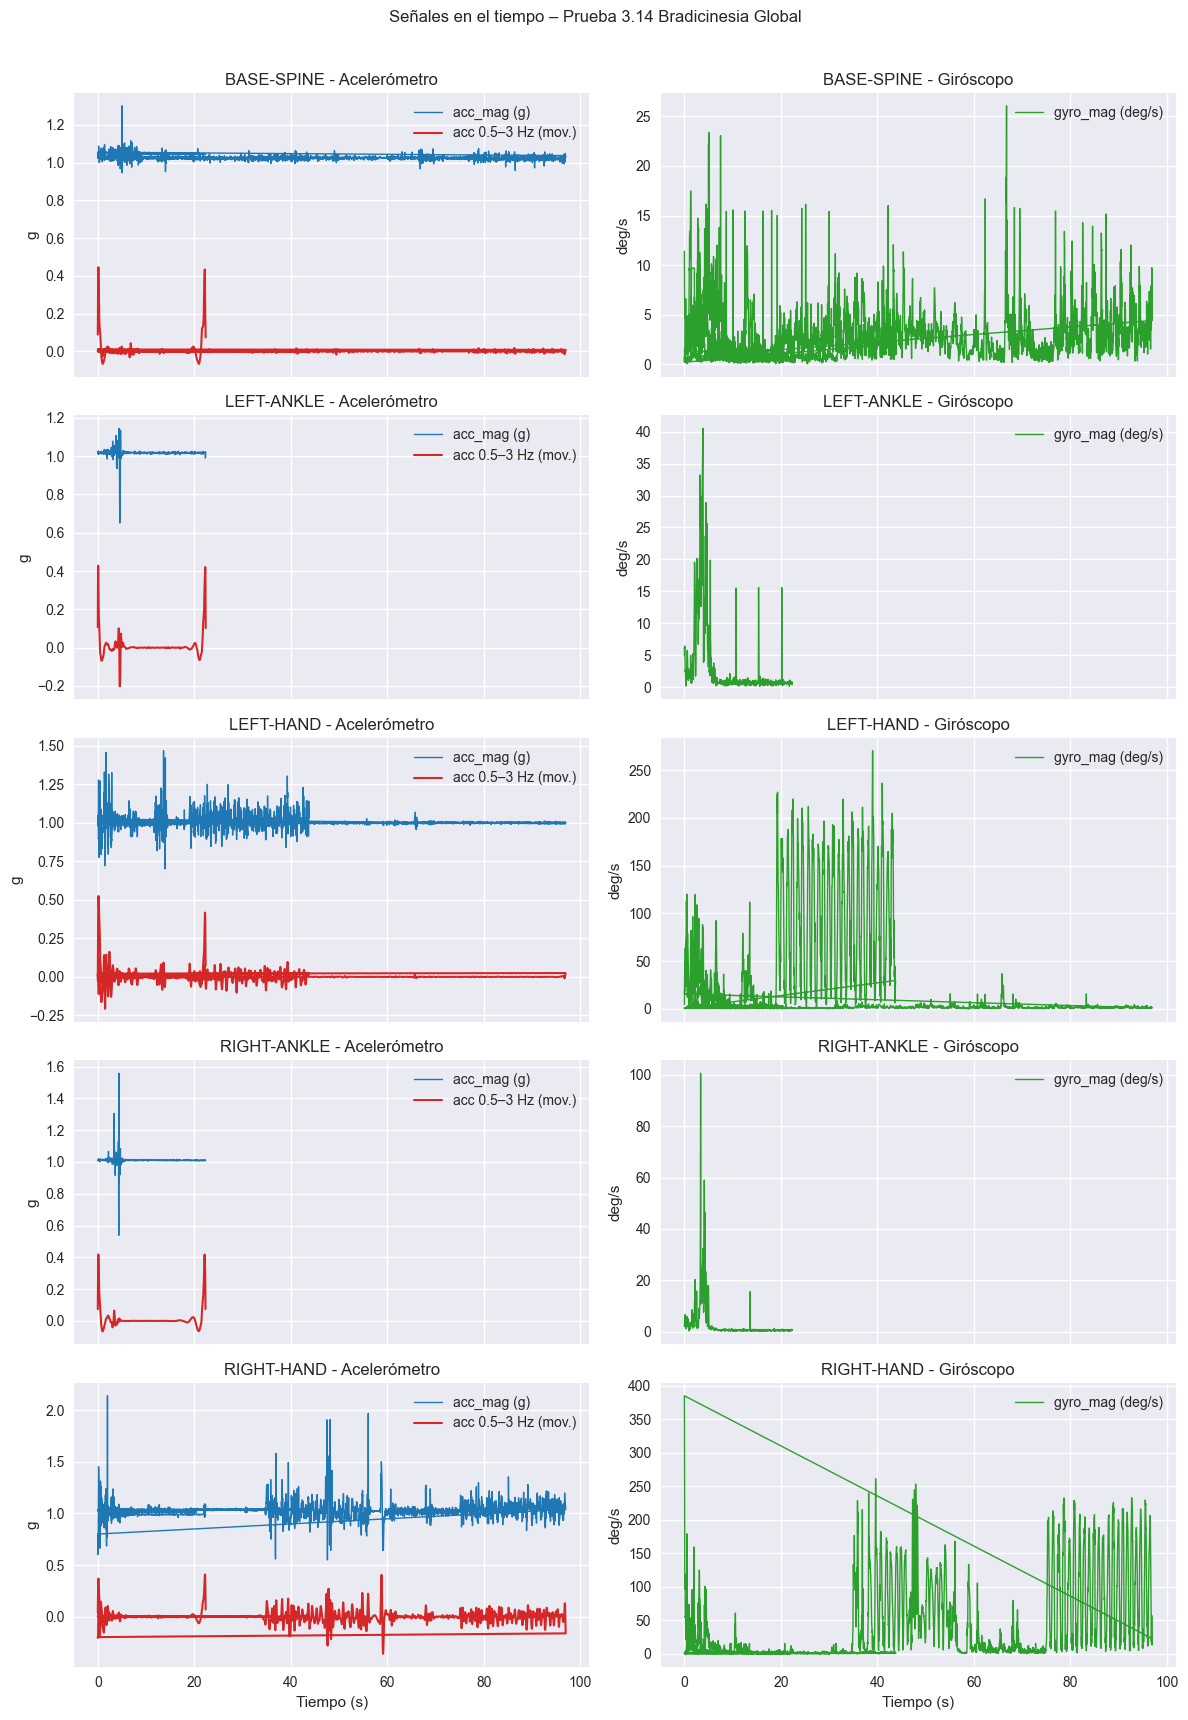

In [21]:
# Gráficos de tiempo – aceleración y giroscopio por dispositivo
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.5*n), sharex=True)
    if n == 1:
        axes = np.array([axes])
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        # Componente de movimiento voluntario (0.5–3 Hz)
        acc_mov = simple_bandpass(acc, fs, 0.5, 3.0) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)

        ax0 = axes[i,0]
        ax0.plot(t, acc, color='#1f77b4', label='acc_mag (g)', linewidth=1)
        ax0.plot(t, acc_mov, color='#d62728', label='acc 0.5–3 Hz (mov.)', linewidth=1.5)
        ax0.set_title(f"{dev} - Acelerómetro")
        ax0.set_ylabel('g')
        ax0.legend(loc='upper right')

        ax1 = axes[i,1]
        ax1.plot(t, gyro, color='#2ca02c', label='gyro_mag (deg/s)', linewidth=1)
        ax1.set_title(f"{dev} - Giróscopo")
        ax1.set_ylabel('deg/s')
        ax1.legend(loc='upper right')
    for j in range(2):
        axes[-1,j].set_xlabel('Tiempo (s)')
    fig.suptitle('Señales en el tiempo – Prueba 3.14 Bradicinesia Global')
    fig.tight_layout(rect=[0,0,1,0.97])
    plt.show()
else:
    print('No hay backend matplotlib disponible.')

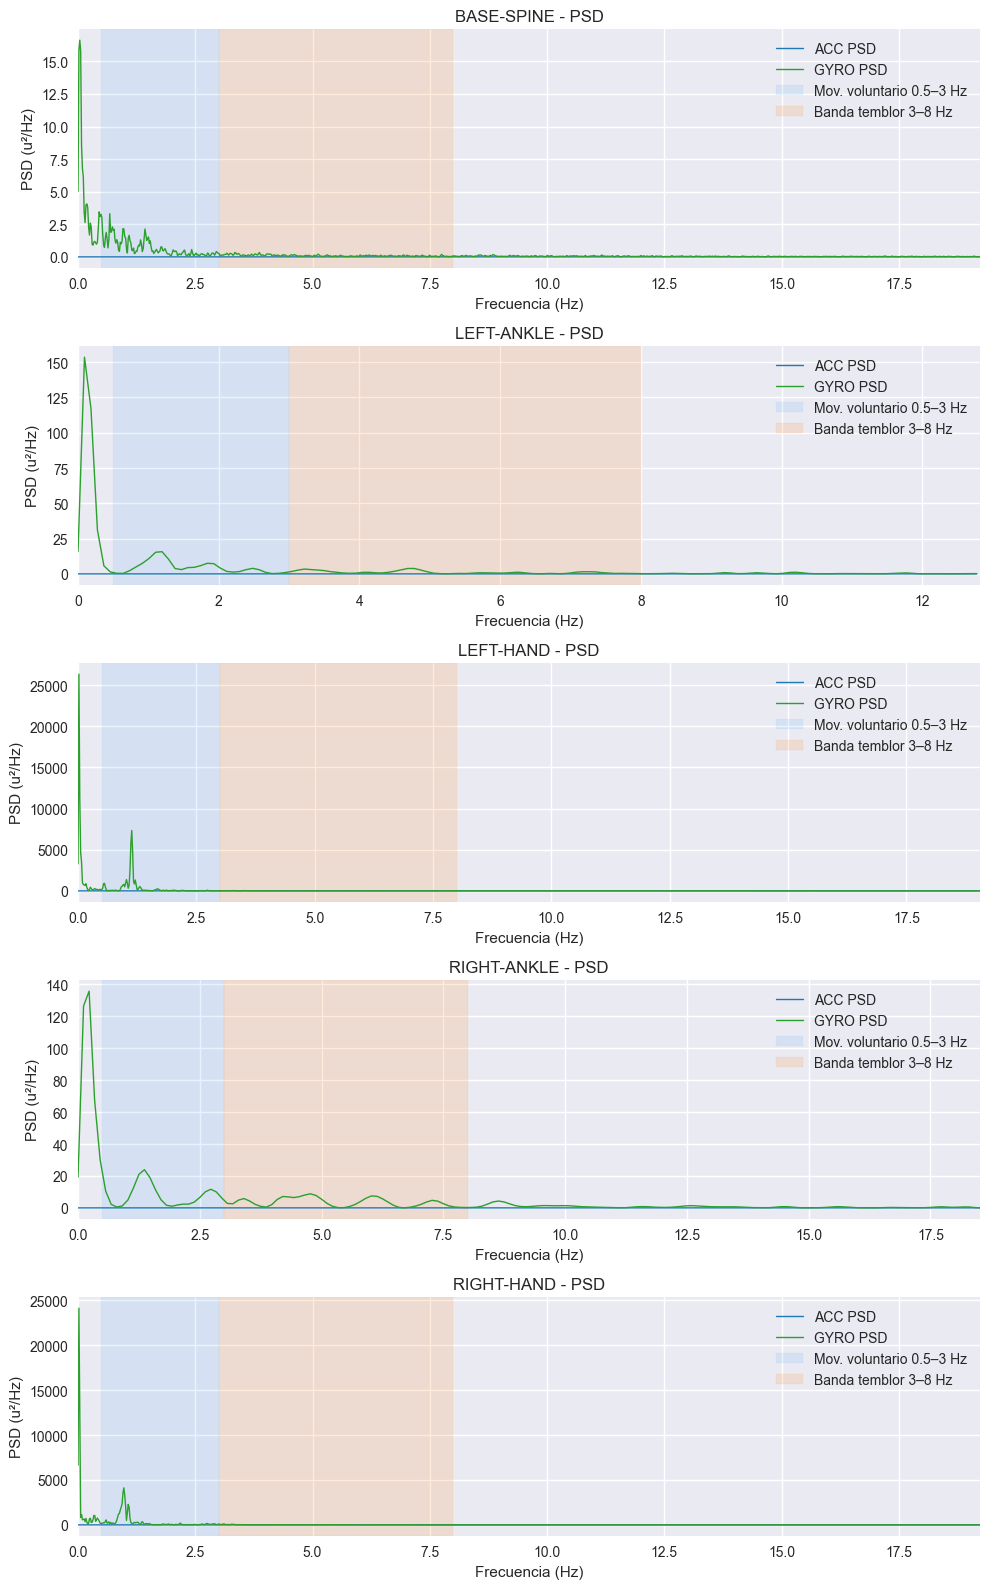

In [22]:
# PSD por dispositivo con bandas de interés
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(0.5, 3.0, color='#2196F3', alpha=0.10, label='Mov. voluntario 0.5–3 Hz')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda temblor 3–8 Hz')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
else:
    print('No hay backend matplotlib disponible.')

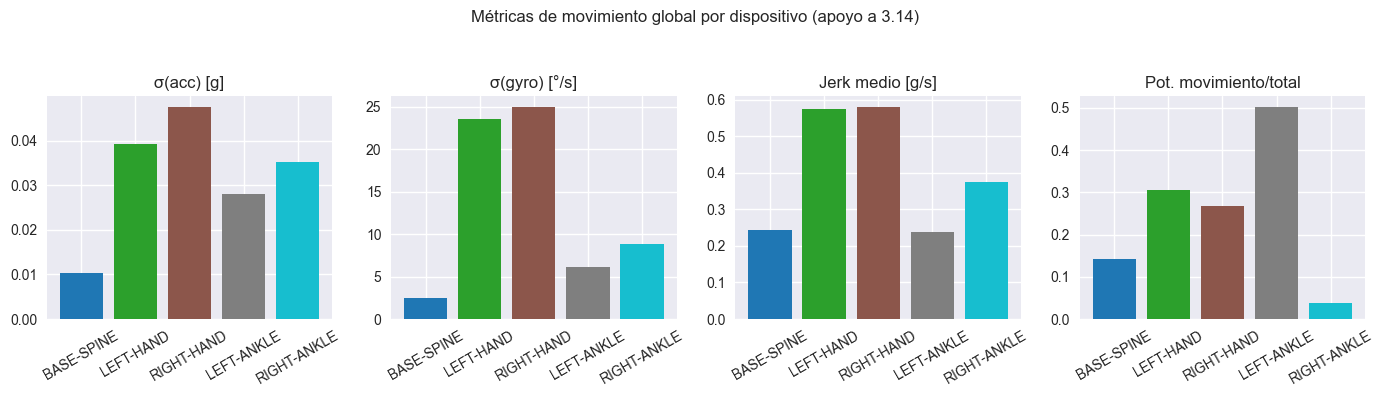

In [23]:
# Comparativa de métricas de bradicinesia entre dispositivos
if _USE_MPL and not brady_df.empty:
    plot_df = brady_df[brady_df['data_status'] == 'available'].copy()
    if plot_df.empty:
        print('No hay IMUs disponibles para graficar.')
    else:
        metrics_to_plot = ['std_acc_mag', 'std_gyro_mag', 'mean_jerk', 'movement_power_ratio']
        labels = ['σ(acc) [g]', 'σ(gyro) [°/s]', 'Jerk medio [g/s]', 'Pot. movimiento/total']
        colors = plt.cm.tab10(np.linspace(0, 1, len(plot_df)))

        fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
        for ax, col, lbl in zip(axes, metrics_to_plot, labels):
            ax.bar(plot_df['device'].astype(str), plot_df[col], color=colors)
            ax.set_title(lbl)
            ax.tick_params(axis='x', rotation=30)
        fig.suptitle('Métricas de movimiento global por dispositivo (apoyo a 3.14)')
        fig.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
else:
    print('No hay datos o matplotlib no disponible.')

## Interpretación para esta tarea

- Este cuaderno usa el enfoque final: **promedios de 3.15, 3.16 y 3.17** para estimar 3.14.
- Se reporta estadística descriptiva por IMU (media y desviación estándar entre pruebas).
- La clasificación se hace en rangos MDS-UPDRS a partir del porcentaje promedio de positividad entre pruebas.
- El objetivo es evitar depender de una sola toma para la inferencia de 3.14.

  RESUMEN – MDS-UPDRS 3.14: Espontaneidad Global del Movimiento
  Paciente con Parkinson


,device,data_status,std_acc_mag,std_acc_mag_std,std_gyro_mag,std_gyro_mag_std,mean_jerk,mean_jerk_std,movement_power_ratio,movement_power_ratio_std,positive_test_pct,mds314_score_from_average,n_tests_used
0,BASE-SPINE,available,0.0104,0.0056,2.4210,0.8517,0.2423,0.0799,0.1416,0.0651,66.6667,3,3
1,LEFT-HAND,available,0.0393,0.0047,23.5422,9.4497,0.5738,0.1445,0.3049,0.0559,50.0000,2,3
2,RIGHT-HAND,available,0.0476,0.0186,24.9605,11.1296,0.5801,0.1607,0.2684,0.0848,50.0000,2,3
3,LEFT-ANKLE,available,0.0281,0.0000,6.0841,0.0000,0.2394,0.0000,0.5019,0.0000,0.0000,0,1
4,RIGHT-ANKLE,available,0.0352,0.0000,8.8182,0.0000,0.3757,0.0000,0.0388,0.0000,100.0000,4,1



Detección global (fórmula validada 3.15–3.17): PARKINSON DETECTADO
Score global 3.14 (promedios 3.15–3.17): 4 / 4

IMUs esperadas (protocolo 3.14): ['BASE-SPINE', 'LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']
IMUs disponibles en la agregación: ['BASE-SPINE', 'LEFT-ANKLE', 'LEFT-HAND', 'RIGHT-ANKLE', 'RIGHT-HAND']
IMUs faltantes: Ninguna

Pruebas integradas en el promedio: 3.15, 3.16, 3.17
Resumen por prueba (promedio por IMU dentro de cada prueba):


,source_test,device,std_acc_mag,std_gyro_mag,mean_jerk,movement_power_ratio,parkinson_flag_validated_rate
0,3.15,BASE-SPINE,0.0055,1.4898,0.1670,0.0500,1.0
1,3.15,LEFT-HAND,0.0352,14.0615,0.4486,0.3836,0.0
2,3.15,RIGHT-HAND,0.0262,9.6579,0.3536,0.3379,0.0
3,3.16,BASE-SPINE,0.0076,2.2249,0.2070,0.1945,0.0
4,3.16,LEFT-HAND,0.0367,36.4394,0.7763,0.2586,0.5
5,3.16,RIGHT-HAND,0.0450,35.8016,0.6770,0.3183,0.5
6,3.17,BASE-SPINE,0.0182,3.5482,0.3529,0.1804,1.0
7,3.17,LEFT-ANKLE,0.0281,6.0841,0.2394,0.5019,0.0
8,3.17,LEFT-HAND,0.0460,20.1257,0.4963,0.2724,1.0
9,3.17,RIGHT-ANKLE,0.0352,8.8182,0.3757,0.0388,1.0


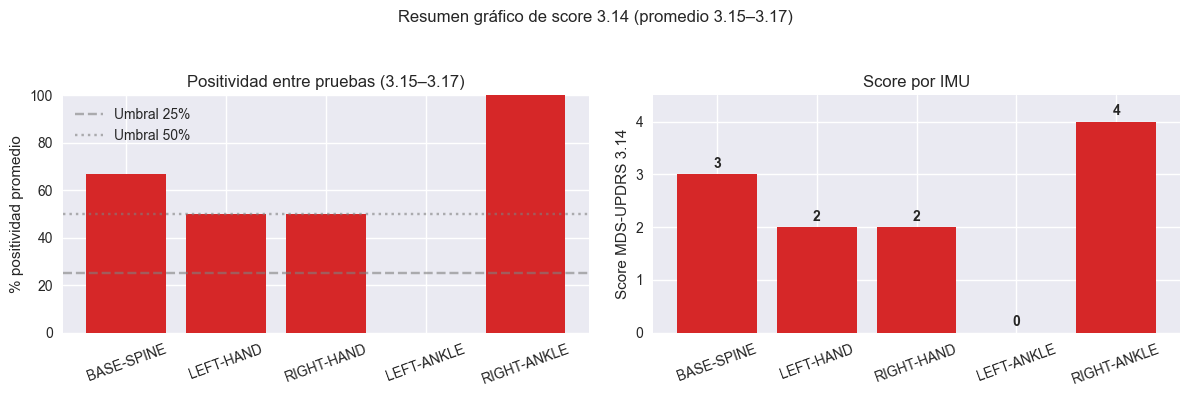


Nota metodológica final:
- 3.14 se estima por agregación de 3.15–3.17 (no por una sola toma puntual).
- Se reportan media y desviación estándar para robustez descriptiva.
- La clasificación MDS-UPDRS se basa en el porcentaje promedio de positividad entre pruebas.


In [25]:
# Resumen clínico y clasificación agregada para 3.14
print('=' * 72)
print('  RESUMEN – MDS-UPDRS 3.14: Espontaneidad Global del Movimiento')
print('  Paciente con Parkinson')
print('=' * 72)

if 'brady_df' in globals() and not brady_df.empty:
    display_cols = [
        'device', 'data_status', 'std_acc_mag', 'std_acc_mag_std',
        'std_gyro_mag', 'std_gyro_mag_std', 'mean_jerk', 'mean_jerk_std',
        'movement_power_ratio', 'movement_power_ratio_std',
        'positive_test_pct', 'mds314_score_from_average', 'n_tests_used'
    ]
    display(brady_df[display_cols].round(4))

    valid_rows = brady_df[brady_df['data_status'] == 'available'].copy()
    if valid_rows.empty:
        global_score = float('nan')
        global_flag = False
        print('\nClasificación global 3.14: No evaluable (sin datos disponibles).')
    else:
        global_score = int(valid_rows['mds314_score_from_average'].max())
        global_flag = bool(valid_rows['parkinson_flag_validated'].any())
        print('\nDetección global (fórmula validada 3.15–3.17):', 'PARKINSON DETECTADO' if global_flag else 'NO DETECTADO')
        print('Score global 3.14 (promedios 3.15–3.17):', global_score, '/ 4')

    print('\nIMUs esperadas (protocolo 3.14):', EXPECTED_314_DEVICES)
    print('IMUs disponibles en la agregación:', devices)
    print('IMUs faltantes:', missing_expected if missing_expected else 'Ninguna')

    print('\nPruebas integradas en el promedio: 3.15, 3.16, 3.17')
    if 'brady_test_df' in globals() and not brady_test_df.empty:
        print('Resumen por prueba (promedio por IMU dentro de cada prueba):')
        display(
            brady_test_df[
                ['source_test', 'device', 'std_acc_mag', 'std_gyro_mag', 'mean_jerk', 'movement_power_ratio', 'parkinson_flag_validated_rate']
            ].round(4)
        )

    # Gráfico final de score (estilo 3.18): porcentaje de positividad y score por IMU
    if _USE_MPL:
        score_plot_df = brady_df[
            (brady_df['data_status'] == 'available')
            & brady_df['mds314_score_from_average'].notna()
            & brady_df['positive_test_pct'].notna()
        ][['device', 'positive_test_pct', 'mds314_score_from_average']].copy()

        if score_plot_df.empty:
            print('\nNo hay datos disponibles para graficar el score 3.14.')
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            pct_colors = ['#d62728' if p > 25 else '#2ca02c' for p in score_plot_df['positive_test_pct']]
            axes[0].bar(score_plot_df['device'].astype(str), score_plot_df['positive_test_pct'], color=pct_colors)
            axes[0].axhline(25, color='gray', linestyle='--', alpha=0.6, label='Umbral 25%')
            axes[0].axhline(50, color='gray', linestyle=':', alpha=0.6, label='Umbral 50%')
            axes[0].set_ylabel('% positividad promedio')
            axes[0].set_title('Positividad entre pruebas (3.15–3.17)')
            axes[0].set_ylim(0, 100)
            axes[0].tick_params(axis='x', rotation=20)
            axes[0].legend()

            score_colors = ['#d62728' if s > 0 else '#2ca02c' for s in score_plot_df['mds314_score_from_average']]
            axes[1].bar(score_plot_df['device'].astype(str), score_plot_df['mds314_score_from_average'], color=score_colors)
            axes[1].set_ylabel('Score MDS-UPDRS 3.14')
            axes[1].set_title('Score por IMU')
            axes[1].set_ylim(0, 4.5)
            axes[1].tick_params(axis='x', rotation=20)
            for _, row in score_plot_df.iterrows():
                axes[1].text(str(row['device']), float(row['mds314_score_from_average']) + 0.12, f"{int(row['mds314_score_from_average'])}", ha='center', fontweight='bold')

            fig.suptitle('Resumen gráfico de score 3.14 (promedio 3.15–3.17)')
            fig.tight_layout(rect=[0, 0, 1, 0.93])
            plt.show()
    else:
        print('\nNo hay backend matplotlib disponible para graficar el score 3.14.')

    print('\nNota metodológica final:')
    print('- 3.14 se estima por agregación de 3.15–3.17 (no por una sola toma puntual).')
    print('- Se reportan media y desviación estándar para robustez descriptiva.')
    print('- La clasificación MDS-UPDRS se basa en el porcentaje promedio de positividad entre pruebas.')
else:
    print('No hay resultados para mostrar.')